# Phase 1 — NASA Battery Dataset: Setup & SOH Label Extraction (v2 — cleaned_dataset format)

**Project:** Battery SOH Estimation using GAF + C-W-DCGAN-GP + CNN-BiLSTM-Attention
**Dataset:** NASA Battery Dataset (PCoE) — Kaggle: `patrickfleith/nasa-battery-dataset`

**Note:** This Kaggle version ships a pre-cleaned format, not raw `.mat` files:
- `cleaned_dataset/metadata.csv` — one row per cycle, with `type` (charge/discharge/impedance),
  `battery_id`, `filename`, and (for discharge cycles) `Capacity`.
- `cleaned_dataset/data/<filename>.csv` — the actual per-cycle signal data
  (`Voltage_measured`, `Current_measured`, `Temperature_measured`, `Current_load`, `Voltage_load`, `Time`).

**Goal of this notebook (Phase 1 only):**
1. Load `metadata.csv` and check which battery IDs are available.
2. For the selected batteries, collect all **discharge** cycles in order, with their `Capacity`.
3. Load the matching per-cycle signal CSVs (Voltage/Current/Temperature/Time).
4. Compute SOH label per discharge cycle: `SOH = (Capacity / rated_capacity) × 100`.
5. Save:
   - `nasa_soh_labels.csv` → one row per discharge cycle (battery_id, cycle_index, capacity, SOH).
   - `nasa_raw_signals.pkl` → per-cycle V/I/T/time arrays, used later in Phase 2 (GAF encoding).
6. Plot degradation curves to sanity-check the data.

This notebook does **not** do GAF encoding, GAN training, or model training — that starts in Phase 2.


## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

BASE_DIR = "/kaggle/input/datasets/patrickfleith/nasa-battery-dataset/cleaned_dataset"
META_PATH = os.path.join(BASE_DIR, "metadata.csv")
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = "/kaggle/working"

meta = pd.read_csv(META_PATH)

# Capacity/Re/Rct sometimes load as strings (mixed with NaN/blank entries) depending on the
# Kaggle CSV export -- force them to numeric so later arithmetic (.min(), .max(), division) works.
for col in ["Capacity", "Re", "Rct"]:
    if col in meta.columns:
        meta[col] = pd.to_numeric(meta[col], errors="coerce")

print(meta.shape)
print(meta.dtypes)
meta.head()


(7565, 10)
type                    object
start_time              object
ambient_temperature      int64
battery_id              object
test_id                  int64
uid                      int64
filename                object
Capacity               float64
Re                     float64
Rct                    float64
dtype: object


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.056058,0.200970
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.053192,0.164734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,NaN,NaN


## 2. Check Available Battery IDs

Before fixing the battery list, check what's actually available in this metadata file —
Kaggle's cleaned version may include more (or different) cells than the original NASA release
used in earlier literature.


In [2]:
available_batteries = sorted(meta["battery_id"].unique())
print(f"{len(available_batteries)} batteries available:")
print(available_batteries)

# Cycle-type counts per battery (sanity check)
print()
print(meta.groupby(["battery_id", "type"]).size().unstack(fill_value=0).head(20))


34 batteries available:
['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054', 'B0055', 'B0056']

type        charge  discharge  impedance
battery_id                              
B0005          170        168        278
B0006          170        168        278
B0007          170        168        278
B0018          134        132         53
B0025           31         28         21
B0026           31         28         21
B0027           31         28         21
B0028           31         28         21
B0029           40         40         17
B0030           40         40         17
B0031           40         40         17
B0032           40         40         17
B0033          197        197         92
B0034          197        197         92
B0036       

In [3]:
# Battery cells to use — adjust this list based on the printed `available_batteries` above.
# B0005, B0006, B0007, B0018 are the most-cited starter set in the literature.
# If any of these are missing from `available_batteries`, swap in available ones (e.g. B0025-B0036 group).
BATTERY_LIST = [b for b in ["B0005", "B0006", "B0007", "B0018"] if b in available_batteries]

if len(BATTERY_LIST) == 0:
    print("None of the default battery IDs were found. Using the first 4 available batteries instead.")
    BATTERY_LIST = available_batteries[:4]

print("Using batteries:", BATTERY_LIST)


Using batteries: ['B0005', 'B0006', 'B0007', 'B0018']


## 3. Extract Discharge Cycles + Capacity per Battery

In [4]:
def get_discharge_rows(battery_id):
    """All discharge-cycle metadata rows for a battery, in chronological order."""
    sub = meta[(meta["battery_id"] == battery_id) & (meta["type"] == "discharge")].copy()
    sub = sub.sort_values("uid").reset_index(drop=True)
    sub["cycle_index"] = np.arange(len(sub))
    return sub

discharge_meta = {b: get_discharge_rows(b) for b in BATTERY_LIST}

for b in BATTERY_LIST:
    print(f"{b}: {len(discharge_meta[b])} discharge cycles, "
          f"capacity range {discharge_meta[b]['Capacity'].min():.3f} - {discharge_meta[b]['Capacity'].max():.3f} Ah")


B0005: 168 discharge cycles, capacity range 1.287 - 1.856 Ah
B0006: 168 discharge cycles, capacity range 1.154 - 2.035 Ah
B0007: 168 discharge cycles, capacity range 1.400 - 1.891 Ah
B0018: 132 discharge cycles, capacity range 1.341 - 1.855 Ah


## 4. Load Raw Signal CSVs for Each Discharge Cycle

In [5]:
def load_signal_csv(filename):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)
    return {
        "voltage": df["Voltage_measured"].to_numpy(dtype=float),
        "current": df["Current_measured"].to_numpy(dtype=float),
        "temperature": df["Temperature_measured"].to_numpy(dtype=float),
        "time": df["Time"].to_numpy(dtype=float),
    }

all_soh_rows = []
all_raw_signals = {}

for battery_id in BATTERY_LIST:
    print(f"Loading {battery_id} ...")
    rows = discharge_meta[battery_id]
    signals_for_battery = {}

    for _, r in rows.iterrows():
        cycle_index = int(r["cycle_index"])
        sig = load_signal_csv(r["filename"])
        signals_for_battery[cycle_index] = sig

        all_soh_rows.append({
            "battery_id": battery_id,
            "cycle_index": cycle_index,
            "capacity_Ah": r["Capacity"],
            "ambient_temperature": r["ambient_temperature"],
            "filename": r["filename"],
        })

    all_raw_signals[battery_id] = signals_for_battery
    print(f"  -> {len(signals_for_battery)} discharge cycles loaded")

soh_df = pd.DataFrame(all_soh_rows)
soh_df.head()


Loading B0005 ...
  -> 168 discharge cycles loaded
Loading B0006 ...
  -> 168 discharge cycles loaded
Loading B0007 ...
  -> 168 discharge cycles loaded
Loading B0018 ...
  -> 132 discharge cycles loaded


,battery_id,cycle_index,capacity_Ah,ambient_temperature,filename
0,B0005,0,1.856487,24,05122.csv
1,B0005,1,1.846327,24,05124.csv
2,B0005,2,1.835349,24,05126.csv
3,B0005,3,1.835263,24,05128.csv
4,B0005,4,1.834646,24,05130.csv


## 5. Compute SOH Label

`SOH = (capacity at cycle n / rated capacity) × 100`

Rated capacity for the B0005/B0006/B0007/B0018 group is **2.0 Ah** (NASA's documented nominal
capacity). If you ended up using a different battery group in Section 2, check the matching
`README_*.txt` file under `cleaned_dataset/extra_infos/` for that group's rated capacity before
trusting this default.


In [6]:
RATED_CAPACITY_AH = 2.0   # change this if BATTERY_LIST was swapped to a different group
EOL_THRESHOLD_PCT = 70.0

soh_df["SOH_percent"] = (soh_df["capacity_Ah"] / RATED_CAPACITY_AH) * 100
soh_df["below_eol"] = soh_df["SOH_percent"] < EOL_THRESHOLD_PCT

eol_summary = (
    soh_df[soh_df["below_eol"]]
    .groupby("battery_id")["cycle_index"]
    .min()
    .rename("eol_cycle_index")
)
print("First cycle below 70% SOH per battery:")
print(eol_summary)

soh_df.head(10)


First cycle below 70% SOH per battery:
battery_id
B0005    124
B0006    108
B0018     96
Name: eol_cycle_index, dtype: int64


,battery_id,cycle_index,capacity_Ah,ambient_temperature,filename,SOH_percent,below_eol
0,B0005,0,1.856487,24,05122.csv,92.824371,False
1,B0005,1,1.846327,24,05124.csv,92.316362,False
2,B0005,2,1.835349,24,05126.csv,91.767460,False
3,B0005,3,1.835263,24,05128.csv,91.763126,False
4,B0005,4,1.834646,24,05130.csv,91.732275,False
5,B0005,5,1.835662,24,05132.csv,91.783083,False
6,B0005,6,1.835146,24,05134.csv,91.757307,False
7,B0005,7,1.825757,24,05136.csv,91.287840,False
8,B0005,8,1.824774,24,05138.csv,91.238693,False
9,B0005,9,1.824613,24,05140.csv,91.230663,False


## 6. Sanity-Check Plots: Capacity / SOH Degradation Curves

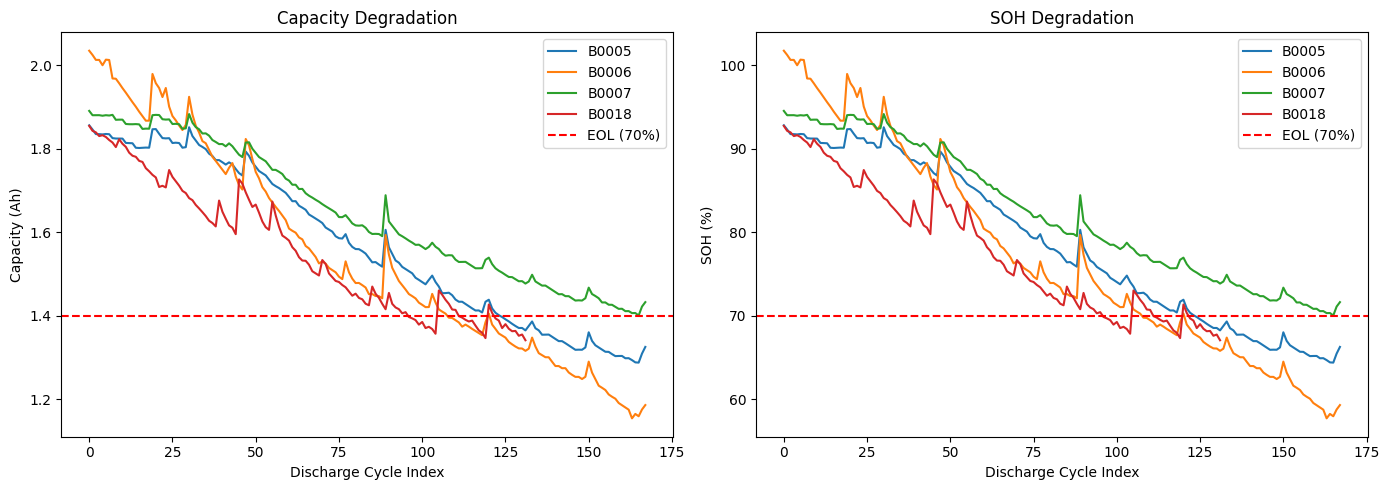

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for battery_id in BATTERY_LIST:
    sub = soh_df[soh_df["battery_id"] == battery_id]
    axes[0].plot(sub["cycle_index"], sub["capacity_Ah"], label=battery_id)
    axes[1].plot(sub["cycle_index"], sub["SOH_percent"], label=battery_id)

axes[0].axhline(RATED_CAPACITY_AH * EOL_THRESHOLD_PCT / 100, color="red", linestyle="--", label="EOL (70%)")
axes[0].set_xlabel("Discharge Cycle Index")
axes[0].set_ylabel("Capacity (Ah)")
axes[0].set_title("Capacity Degradation")
axes[0].legend()

axes[1].axhline(EOL_THRESHOLD_PCT, color="red", linestyle="--", label="EOL (70%)")
axes[1].set_xlabel("Discharge Cycle Index")
axes[1].set_ylabel("SOH (%)")
axes[1].set_title("SOH Degradation")
axes[1].legend()

plt.tight_layout()
plt.show()


In [8]:
# Note: some cells (e.g. B0005/B0006/B0018) show "capacity regeneration" -- small upward jumps
# caused by rest-period relaxation effects. This is expected and well documented in NASA PCoE
# literature, not a data error.

soh_df.groupby("battery_id")["SOH_percent"].agg(["count", "min", "max"])


,count,min,max
battery_id,,,
B0005,168,64.372626,92.824371
B0006,168,57.690917,101.766880
B0007,168,70.022762,94.552615
B0018,132,67.052572,92.750226


## 7. Sanity-Check Plot: Raw Voltage/Current/Temperature for One Cycle

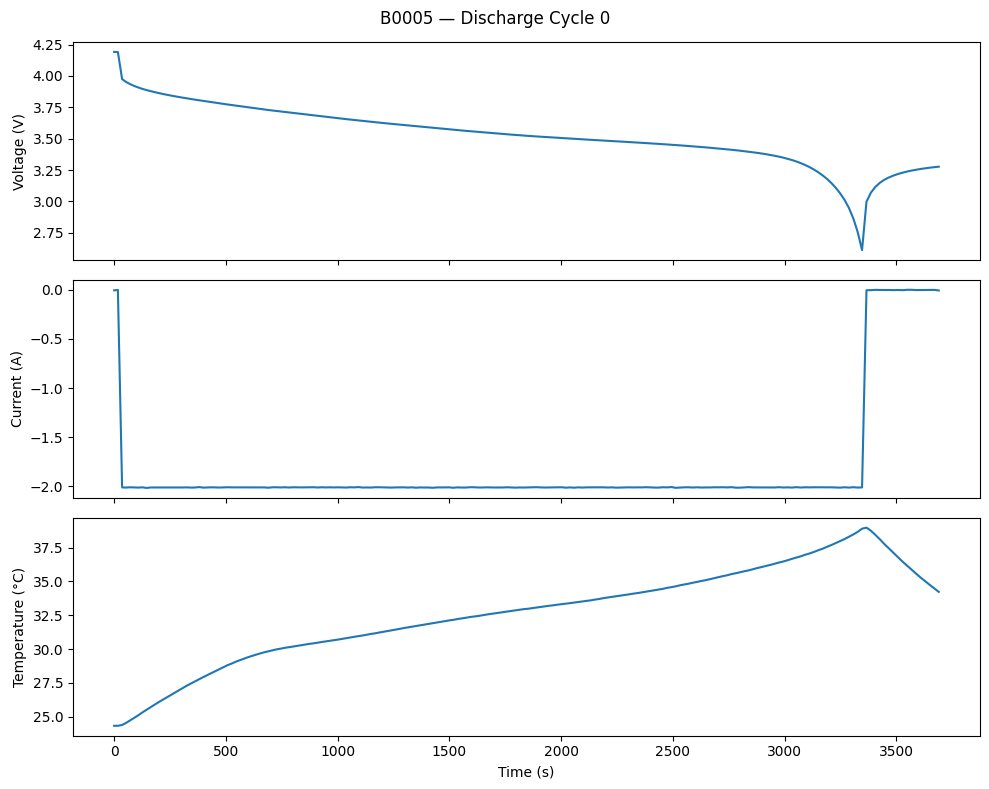

Signal lengths (will need downsampling to a fixed length, e.g. 128, in Phase 2):
Voltage: 197 | Current: 197 | Temperature: 197


In [9]:
example_battery = BATTERY_LIST[0]
example_cycle = 0

sig = all_raw_signals[example_battery][example_cycle]

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(sig["time"], sig["voltage"])
axes[0].set_ylabel("Voltage (V)")
axes[1].plot(sig["time"], sig["current"])
axes[1].set_ylabel("Current (A)")
axes[2].plot(sig["time"], sig["temperature"])
axes[2].set_ylabel("Temperature (°C)")
axes[2].set_xlabel("Time (s)")
fig.suptitle(f"{example_battery} — Discharge Cycle {example_cycle}")
plt.tight_layout()
plt.show()

print("Signal lengths (will need downsampling to a fixed length, e.g. 128, in Phase 2):")
print("Voltage:", len(sig["voltage"]), "| Current:", len(sig["current"]), "| Temperature:", len(sig["temperature"]))


## 8. Save Outputs for Phase 2

In [10]:
soh_csv_path = os.path.join(OUTPUT_DIR, "nasa_soh_labels.csv")
soh_df.to_csv(soh_csv_path, index=False)
print("Saved:", soh_csv_path)

raw_pkl_path = os.path.join(OUTPUT_DIR, "nasa_raw_signals.pkl")
with open(raw_pkl_path, "wb") as f:
    pickle.dump(all_raw_signals, f)
print("Saved:", raw_pkl_path)

print("\nPhase 1 complete.")
print(f"Total discharge cycles across {len(BATTERY_LIST)} batteries: {len(soh_df)}")


Saved: /kaggle/working/nasa_soh_labels.csv
Saved: /kaggle/working/nasa_raw_signals.pkl

Phase 1 complete.
Total discharge cycles across 4 batteries: 636


---
### Next: Phase 2 (separate notebook)

- Downsample each cycle's V/I/T signal to a fixed length (e.g. 128 points).
- Min-Max scale to [0,1] and apply GASF transform.
- Stack V/I/T GASF images into a 3-channel RGB GAF image, labelled with the SOH value from
  `nasa_soh_labels.csv`.
- Validate inverse-GAF reconstruction before moving to GAN training.
